In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

In [6]:
leetcode_questions_df.head()

,username,country,contest_url,num_of_contest,is_weekly,rank,score,question_number,question_language,question_code,...,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated,has_camel_case,has_snake_case
0,zzhnb,Canada,https://leetcode.com/contest/weekly-contest-39...,390,True,403,18,4,python,"class node:\n def __init__(self, minsize = ...",...,0.121212,0.0,3139.0,2839.0,1277.0,0.028753,1021,5,False,False
1,zzhnb,Canada,https://leetcode.com/contest/weekly-contest-39...,390,True,403,18,3,python,"class Solution:\n def mostFrequentIDs(self,...",...,0.040000,0.0,3139.0,1562.0,965.0,0.028753,434,5,False,False
2,zzhnb,Canada,https://leetcode.com/contest/weekly-contest-39...,390,True,403,18,2,python,"class Solution:\n def minOperations(self, k...",...,0.055556,0.0,3139.0,597.0,367.0,0.028753,272,5,False,False
3,zzhnb,Canada,https://leetcode.com/contest/weekly-contest-39...,390,True,403,18,1,python,class Solution:\n def maximumLengthSubstrin...,...,0.043478,0.0,3139.0,230.0,0.0,0.028753,332,5,False,False
4,zzhnb,Canada,https://leetcode.com/contest/weekly-contest-37...,374,True,1095,7,2,python,class Solution:\n def minimumAddedCoins(sel...,...,0.136364,0.0,941.0,941.0,764.0,0.028863,418,5,False,False


In [7]:
leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [8]:
leetcode_questions_df.global_rank_percentile.describe()

count    61834.000000
mean         0.031235
std          0.072937
min          0.000001
25%          0.001015
50%          0.005182
75%          0.025174
max          1.000000
Name: global_rank_percentile, dtype: float64

<Axes: >

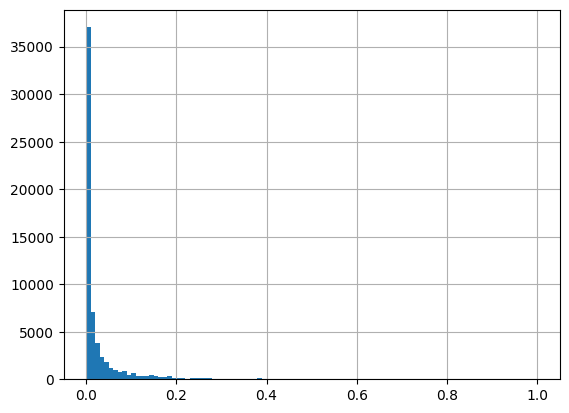

In [10]:
leetcode_questions_df.global_rank_percentile.hist(bins=100)

In [15]:
leetcode_questions_df.groupby(leetcode_questions_df.username).global_rank_percentile.count().sort_values(ascending=False).head(400)

username
wenboz           129
mkawa222         123
uwi              115
nevergiveup      115
Tinky1224        112
                ... 
divyansh_7310     34
gourabsingha1     33
LuckyBoy88        33
surajpatel        33
petabyte          33
Name: global_rank_percentile, Length: 400, dtype: int64

In [16]:
leetcode_questions_df.global_rank_percentile[leetcode_questions_df.username == 'petabyte']

17604    0.000428
17605    0.000428
17606    0.000428
17607    0.000428
17608    0.000428
17609    0.000428
17610    0.000428
17611    0.000428
17612    0.000428
17613    0.000428
17614    0.000428
17615    0.000428
17616    0.000428
17617    0.000428
17618    0.000428
17619    0.000428
17620    0.000428
17621    0.000428
17622    0.000428
17623    0.000428
17624    0.000428
17625    0.000428
17626    0.000428
17627    0.000428
17628    0.000428
17629    0.000428
17630    0.000428
17631    0.000428
17632    0.000428
17633    0.000428
17634    0.000428
17635    0.000428
17636    0.000428
Name: global_rank_percentile, dtype: float64

In [14]:
leetcode_questions_df.groupby(leetcode_questions_df.username).global_rank_percentile.mean()

username
0004Lohani      0.344523
0007glitcher    0.007267
001cat          0.050867
003213          0.000831
007Harsh-       0.018142
                  ...   
zubair_aquif    0.167028
zubinshah       0.003989
zunyiliu        0.000244
zysxbhp         0.006311
zzhnb           0.028828
Name: global_rank_percentile, Length: 5727, dtype: float64

In [22]:
leetcode_questions_df.user_global_rank.describe().apply(lambda x: format(x, 'f'))

count      61834.000000
mean      143626.100155
std       335380.161502
min            5.000000
25%         4666.000000
50%        23830.000000
75%       115755.000000
max      4598201.000000
Name: user_global_rank, dtype: object

<Axes: >

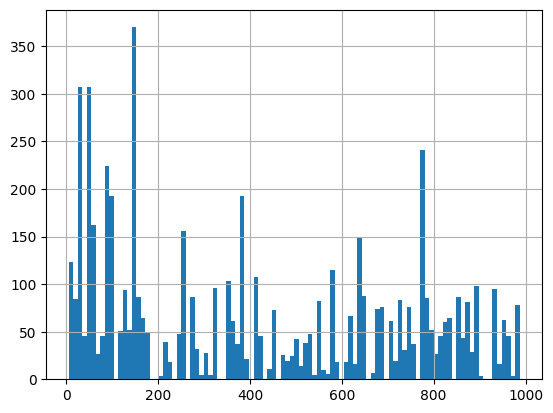

In [24]:
leetcode_questions_df.user_global_rank[leetcode_questions_df.user_global_rank < 1000].hist(bins = 100)

(array([5.6522e+04, 3.2470e+03, 1.0730e+03, 4.3200e+02, 2.9400e+02,
        1.2900e+02, 7.2000e+01, 2.4000e+01, 3.0000e+01, 1.1000e+01]),
 array([5.0000000e+00, 4.5982460e+05, 9.1964420e+05, 1.3794638e+06,
        1.8392834e+06, 2.2991030e+06, 2.7589226e+06, 3.2187422e+06,
        3.6785618e+06, 4.1383814e+06, 4.5982010e+06]),
 <BarContainer object of 10 artists>)

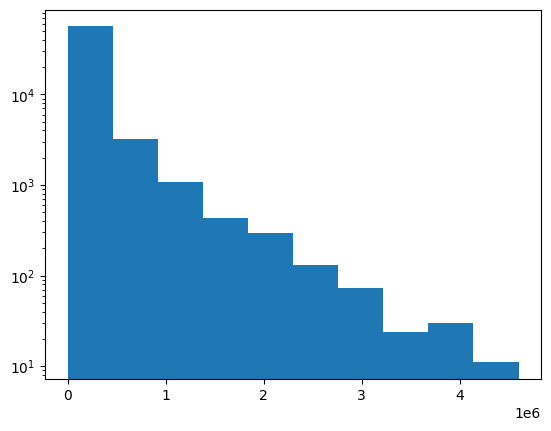

In [28]:
import matplotlib.pyplot as plt

plt.hist(leetcode_questions_df.user_global_rank, log=True)

In [17]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part2 feature-creation/code_features_extracts.csv')
leetcode_questions_df['num_of_contest'] = leetcode_questions_df.num_of_contest.astype('category')
leetcode_questions_df['question_number'] = leetcode_questions_df.question_number.astype('category')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     61834 non-null  object  
 1   country                      61834 non-null  object  
 2   contest_url                  61834 non-null  object  
 3   num_of_contest               61834 non-null  category
 4   finish_time                  61834 non-null  object  
 5   is_weekly                    61834 non-null  bool    
 6   rank                         61834 non-null  int64   
 7   score                        61834 non-null  int64   
 8   user_global_rank             61834 non-null  float64 
 9   question_number              61834 non-null  category
 10  question_language            61834 non-null  object  
 11  question_code                61834 non-null  object  
 12  question_finish_time         61834 non-null  object  
 13  n

In [ ]:
leetcode_questions_df['contest_finish_time_total_seconds'] = pd.to_timedelta(leetcode_questions_df['finish_time']).dt.total_seconds()
leetcode_questions_df['question_finish_time_total_seconds'] = pd.to_timedelta(leetcode_questions_df['question_finish_time']).dt.total_seconds()
leetcode_questions_df.drop('finish_time', axis = 1, inplace=True)
leetcode_questions_df.drop('question_finish_time', axis = 1, inplace=True)

In [ ]:
leetcode_questions_df.sort_values(by=['username', 'num_of_contest', 'question_finish_time_total_seconds'], ascending=False , inplace=True)
leetcode_questions_df['time_spent_per_question'] = leetcode_questions_df.groupby(['username', 'num_of_contest'])['question_finish_time_total_seconds'].diff(periods=-1).fillna(0)

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['user_global_rank'] < 10000]
leetcode_questions_df['global_rank_percentile'] = leetcode_questions_df.user_global_rank / leetcode_questions_df.user_global_rank.max()
leetcode_questions_df.drop('user_global_rank', axis = 1, inplace=True)

<ipython-input-6-1386d8b700e5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leetcode_questions_df['global_rank_percentile'] = leetcode_questions_df.user_global_rank / leetcode_questions_df.user_global_rank.max()
<ipython-input-6-1386d8b700e5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leetcode_questions_df.drop('user_global_rank', axis = 1, inplace=True)


In [ ]:
leetcode_questions_df['question_code_length'] = leetcode_questions_df.question_code.str.len()

<ipython-input-7-a4ff48516976>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leetcode_questions_df['question_code_length'] = leetcode_questions_df.question_code.str.len()


In [ ]:
leetcode_questions_df.groupby('username')['num_of_contest'].nunique()

username
003213          1
0xFFFFFFFF      8
11srj11         1
19JE0894        3
1v9n418vn51     8
               ..
zhutianqi      11
zitman          4
zokumyoin      18
zoro2369        8
zunyiliu       12
Name: num_of_contest, Length: 1090, dtype: int64

In [ ]:
num_contests_participated_df = leetcode_questions_df.groupby('username')['num_of_contest'].nunique().reset_index()
num_contests_participated_df = num_contests_participated_df.rename(columns={"num_of_contest": "num_contests_participated"})
leetcode_questions_df = leetcode_questions_df.merge(num_contests_participated_df, on='username', how='left')

In [ ]:
def has_camel_case(name):
    return bool(re.search(r'[a-z]+[A-Z]', name))

def has_snake_case(name):
    return bool(re.search(r'_', name))


leetcode_questions_df['has_camel_case'] = leetcode_questions_df['names_set'].apply(lambda names: any(has_camel_case(name) for name in names))
leetcode_questions_df['has_snake_case'] = leetcode_questions_df['names_set'].apply(lambda names: any(has_snake_case(name) for name in names))

In [ ]:
leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22130 entries, 0 to 22129
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   username                            22130 non-null  object  
 1   country                             22130 non-null  object  
 2   contest_url                         22130 non-null  object  
 3   num_of_contest                      22130 non-null  category
 4   is_weekly                           22130 non-null  bool    
 5   rank                                22130 non-null  int64   
 6   score                               22130 non-null  int64   
 7   question_number                     22130 non-null  category
 8   question_language                   22130 non-null  object  
 9   question_code                       22130 non-null  object  
 10  number_of_lines                     22130 non-null  int64   
 11  names_set                   

In [ ]:
leetcode_questions_df.to_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv', index=False)